In [16]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [7]:
df=pd.read_csv(r'C:\Users\Me\Downloads\DS_project_1\cleaned_abe_books.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 902 entries, 0 to 901
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Book_title       902 non-null    object 
 1   price            902 non-null    float64
 2   shipping_price   902 non-null    float64
 3   book_quantity    902 non-null    int64  
 4   cover_type       902 non-null    object 
 5   book_condition   902 non-null    object 
 6   Author           902 non-null    object 
 7   published_by     902 non-null    object 
 8   published_year   902 non-null    int64  
 9   seller_name      902 non-null    object 
 10  seller_location  902 non-null    object 
 11  seller_rate      902 non-null    int64  
 12  seller_country   902 non-null    object 
dtypes: float64(2), int64(3), object(8)
memory usage: 91.7+ KB


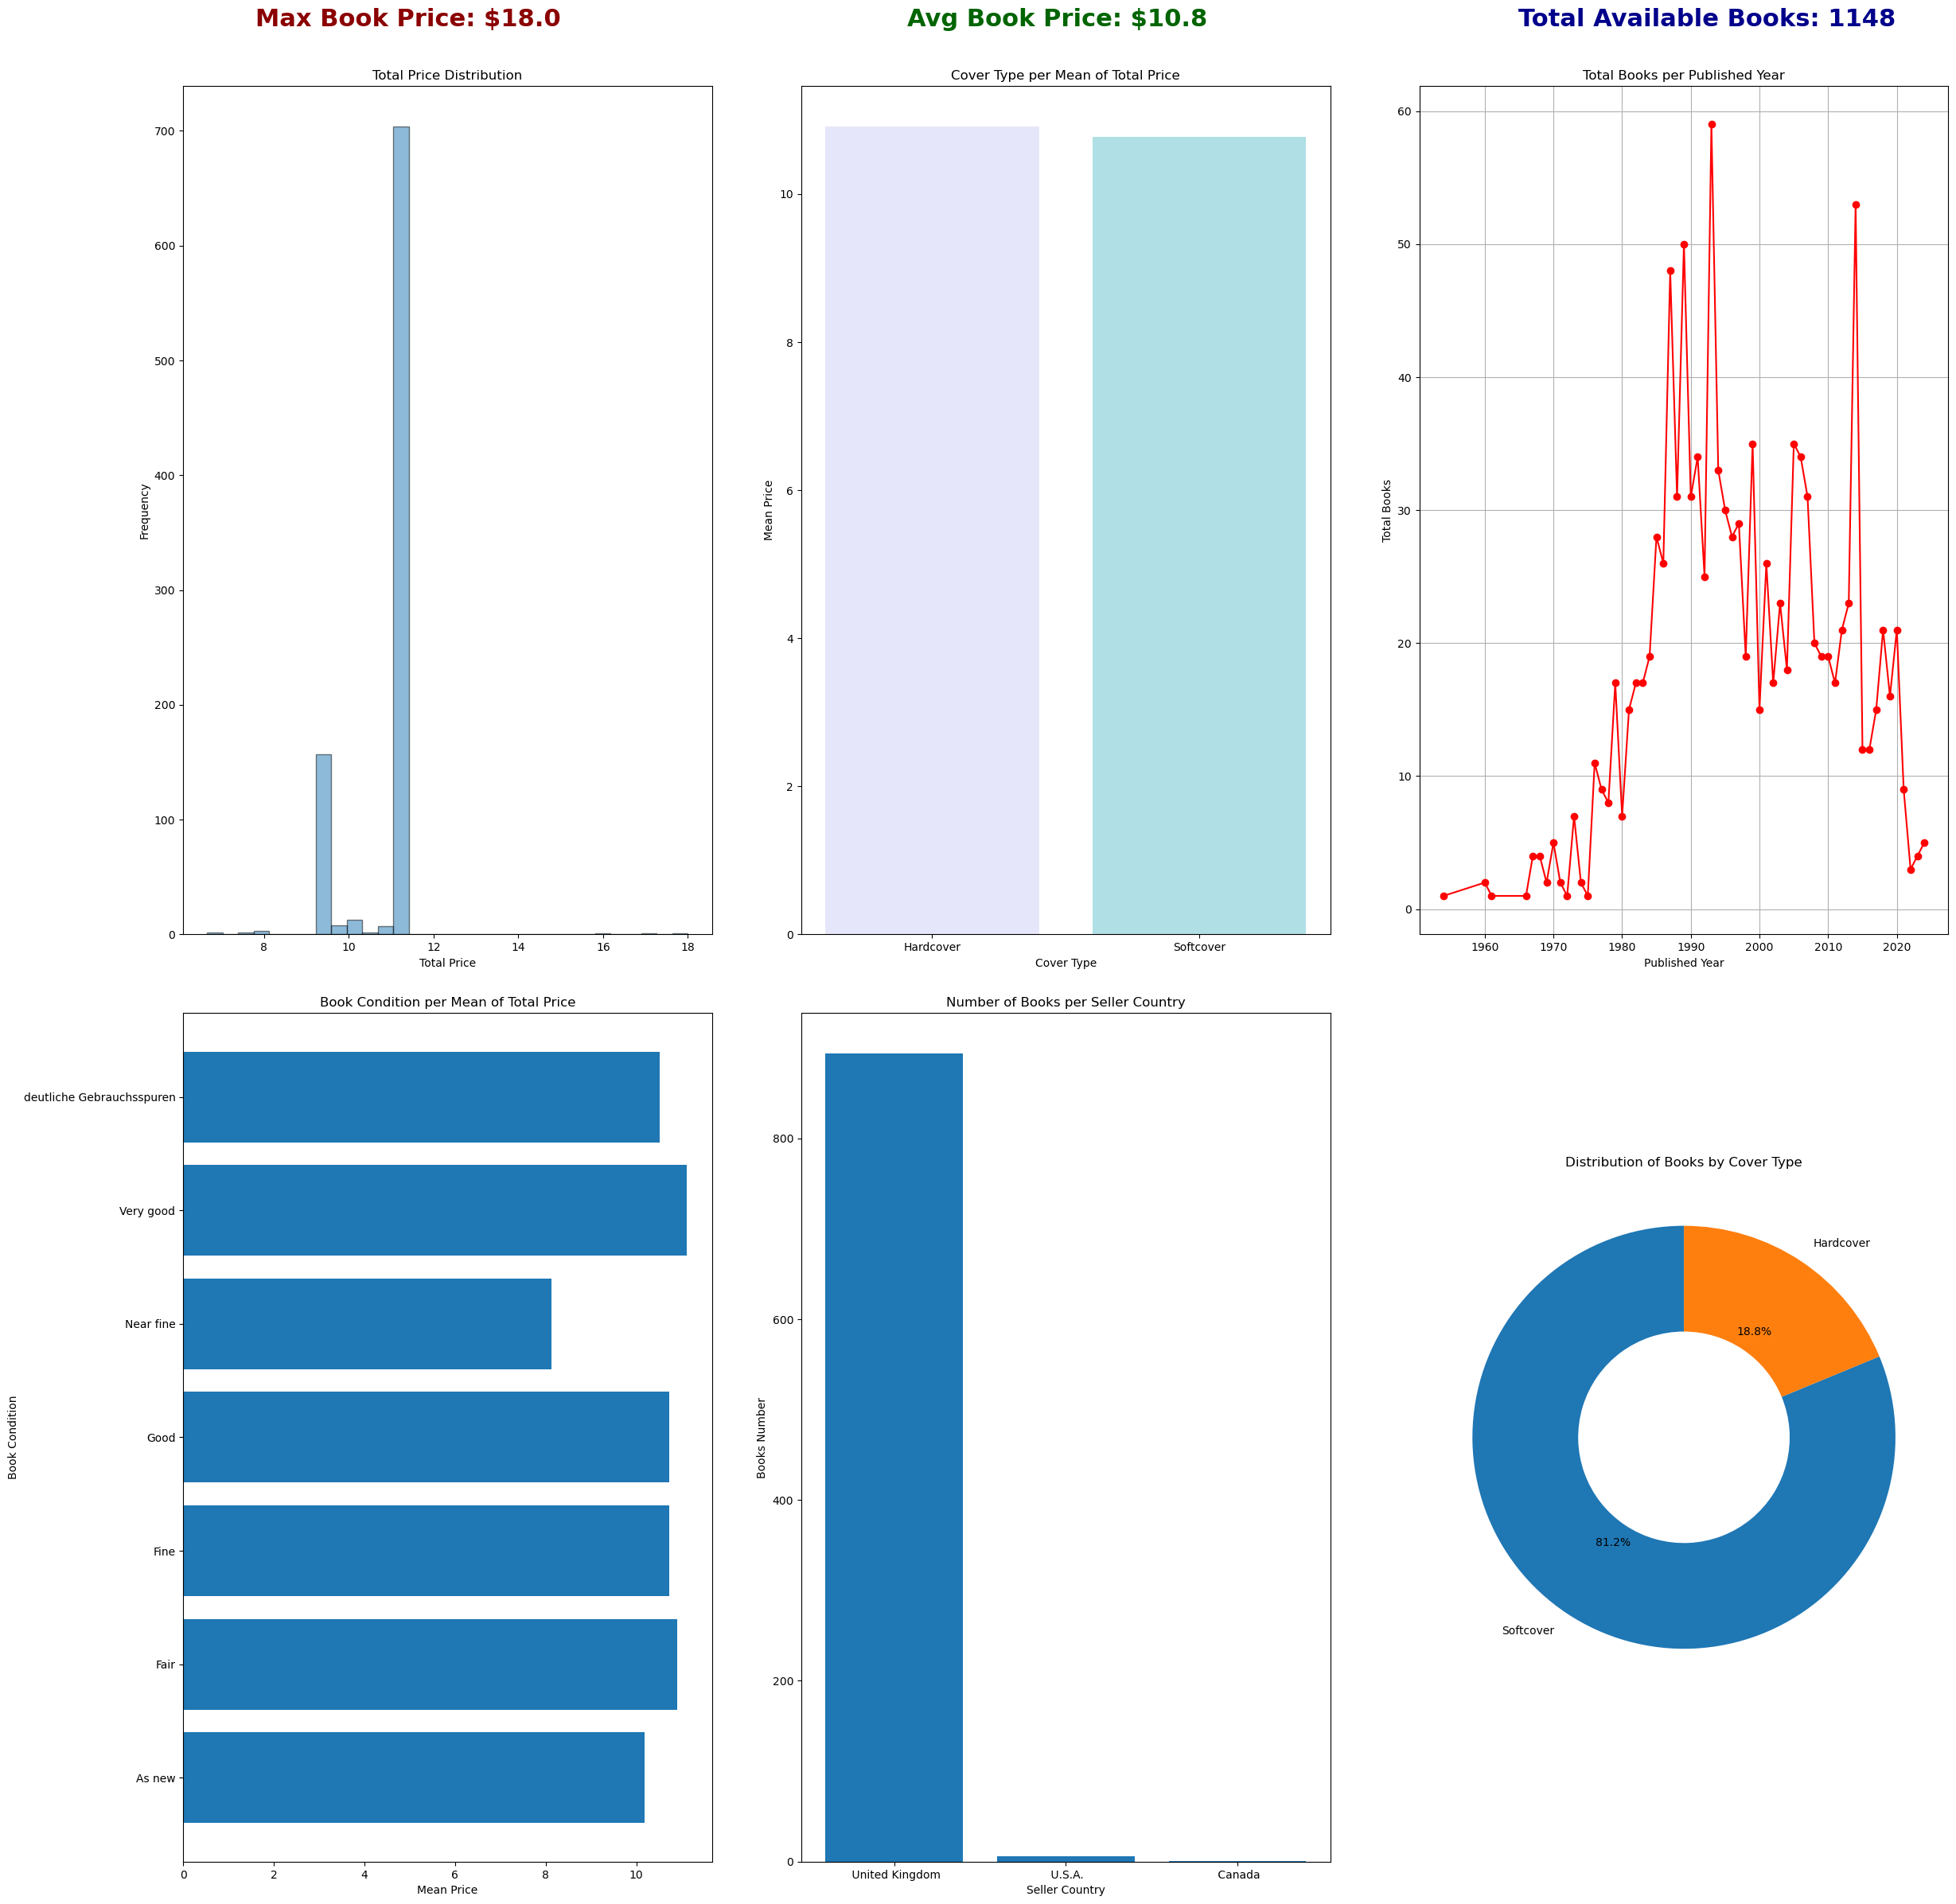

In [68]:
import matplotlib.pyplot as plt
import math
import pandas as pd

df['total_price'] = round(df['price'], 2) + round(df['shipping_price'], 2)

max_price = round(df['total_price'].max(), 2)
avg_price = round(df['total_price'].mean(), 2)
available_books = df['book_quantity'].sum()

fig, axes = plt.subplots(2, 3, figsize=(24, 24))
fig.tight_layout(pad=5)


# Histogram for total price
axes[0,0].hist(df['total_price'],
               bins=math.ceil(math.sqrt(len(df['total_price']))),
               range=(df['total_price'].min(), df['total_price'].max()),
               alpha=0.5,
               edgecolor='black')
axes[0,0].set_title('Total Price Distribution')
axes[0,0].set_xlabel('Total Price')
axes[0,0].set_ylabel('Frequency')

# Cover type effect on total price
df_to_bar = df.groupby('cover_type')['total_price'].mean().to_frame().reset_index()
axes[0,1].bar(df_to_bar['cover_type'],
              df_to_bar['total_price'],
              color=['#E6E6FA', '#B0E0E6'])
axes[0,1].set_title('Cover Type per Mean of Total Price')
axes[0,1].set_xlabel('Cover Type')
axes[0,1].set_ylabel('Mean Price')

# Book condition effect on total price
df_to_bar_2 = df.groupby('book_condition')['total_price'].mean().to_frame().reset_index()
axes[1,0].barh(df_to_bar_2['book_condition'],
               df_to_bar_2['total_price'])
axes[1,0].set_title('Book Condition per Mean of Total Price')
axes[1,0].set_xlabel('Mean Price')
axes[1,0].set_ylabel('Book Condition')

# Published year and book quantity line chart
df_to_line_chart = df.sort_values(by='published_year', ascending=True).groupby('published_year')['book_quantity'].sum().to_frame().reset_index()
axes[0,2].plot(df_to_line_chart['published_year'], df_to_line_chart['book_quantity'], color='red', marker='o')
axes[0,2].grid(True)
axes[0,2].set_title('Total Books per Published Year')
axes[0,2].set_xlabel('Published Year')
axes[0,2].set_ylabel('Total Books')

# Seller country bar chart
df_to_bar_3 = df['seller_country'].value_counts().to_frame().reset_index()
axes[1,1].bar(df_to_bar_3['seller_country'], df_to_bar_3['count'])
axes[1,1].set_title('Number of Books per Seller Country')
axes[1,1].set_xlabel('Seller Country')
axes[1,1].set_ylabel('Books Number')

# Pie chart for cover type
df_to_pie = df['cover_type'].value_counts().to_frame().reset_index()
axes[1,2].pie(df_to_pie['count'], 
              labels=df_to_pie['cover_type'], 
              autopct='%1.1f%%', 
              startangle=90, 
              wedgeprops={'width':0.5})
axes[1,2].set_title('Distribution of Books by Cover Type')

fig.text(0.16, 1, f'Max Book Price: ${max_price}', ha='center', fontsize=22, fontweight='bold', color='darkred')
fig.text(0.5, 1, f'Avg Book Price: ${avg_price}', ha='center', fontsize=22, fontweight='bold', color='darkgreen')
fig.text(0.84, 1, f'Total Available Books: {available_books}', ha='center', fontsize=22, fontweight='bold', color='darkblue')


plt.show()
